# 03. Transformer baseline

### Что делаю?

Baseline беру из того же семейства, которое уже использовал в прошлых DL домашках -- обычный Transformer Encoder с `MultiheadAttention`, residual, LayerNorm и FFN.

Для временных рядов вместо image patches каждый timestamp становится токеном с 9 признаками. Добавляю `CLS` token и positional embedding.

Параметры: `dim=72`, `depth=4`, `heads=4`, `mlp_ratio=2`. Получается почти тот же parameter budget, что у двух EdgeMTSC вариантов, но отдельного IMP-механизма нет.


In [1]:
from pathlib import Path
from copy import deepcopy
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
(ROOT / "figures").mkdir(exist_ok=True)
(ROOT / "results").mkdir(exist_ok=True)

data = np.load(ROOT / "data/uci_har_raw.npz")
X_train = data["X_train"]
y_train = data["y_train"]
subjects_train = data["subjects_train"]
X_test = data["X_test"]
y_test = data["y_test"]

CLASS_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING",
]

SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 35
PATIENCE = 7
LR = 8e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.05

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: mps


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def standardize(X_fit, X_other):
    mean = X_fit.mean(axis=(0, 2), keepdims=True)
    std = X_fit.std(axis=(0, 2), keepdims=True) + 1e-6
    return (X_fit - mean) / std, (X_other - mean) / std, mean, std


def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss_sum += criterion(logits, y).item() * len(y)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())

    return {
        "loss": loss_sum / len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
    }


def fit(model, train_loader, val_loader=None, epochs=MAX_EPOCHS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_f1": []}
    best_state = deepcopy(model.state_dict())
    best_f1, best_epoch = -1.0, 0
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            loss_sum += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            total += len(y)

        scheduler.step()
        history["train_loss"].append(loss_sum / total)
        history["train_acc"].append(correct / total)

        if val_loader is not None:
            val = evaluate(model, val_loader)
            history["val_loss"].append(val["loss"])
            history["val_f1"].append(val["macro_f1"])

            if val["macro_f1"] > best_f1:
                best_f1 = val["macro_f1"]
                best_epoch = epoch
                best_state = deepcopy(model.state_dict())

            if epoch - best_epoch >= PATIENCE:
                break

    if val_loader is not None:
        model.load_state_dict(best_state)

    return history, best_epoch, time.perf_counter() - started


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def sync():
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def latency_ms(model, X, repeats=100):
    model.eval()
    batch = torch.tensor(X[:BATCH_SIZE], dtype=torch.float32, device=device)
    for _ in range(20):
        model(batch)
    sync()
    started = time.perf_counter()
    for _ in range(repeats):
        model(batch)
    sync()
    return (time.perf_counter() - started) * 1000 / repeats / len(batch)


In [3]:
class TransformerBlock(nn.Module):
    def __init__(self, dim=72, heads=4, mlp_ratio=2, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * mlp_ratio, dim),
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.drop = nn.Dropout(dropout)
        self.last_attention = None

    def forward(self, x, save_attention=False):
        attn, weights = self.attn(x, x, x, need_weights=save_attention)
        self.last_attention = weights.detach().cpu() if save_attention else None
        x = self.norm1(x + self.drop(attn))
        return self.norm2(x + self.drop(self.ff(x)))


class TimeSeriesTransformer(nn.Module):
    # Архитектуру держу близкой к TinyViT из прошлой DL домашки.
    def __init__(self, dim=72, depth=4, heads=4, mlp_ratio=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(9, dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 129, dim))
        self.layers = nn.ModuleList([
            TransformerBlock(dim, heads, mlp_ratio, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, 6)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x, save_attention=False):
        x = self.input_proj(x.transpose(1, 2))
        cls = self.cls_token.expand(len(x), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed

        for layer in self.layers:
            x = layer(x, save_attention=save_attention)

        return self.head(self.norm(x[:, 0]))


In [4]:
set_seed(SEED)
model = TimeSeriesTransformer().to(device)
print(model)
print("params:", f"{count_parameters(model):,}")


TimeSeriesTransformer(
  (input_proj): Linear(in_features=9, out_features=72, bias=True)
  (layers): ModuleList(
    (0-3): 4 x TransformerBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=72, out_features=72, bias=True)
      )
      (ff): Sequential(
        (0): Linear(in_features=72, out_features=144, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=144, out_features=72, bias=True)
      )
      (norm1): LayerNorm((72,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((72,), eps=1e-05, elementwise_affine=True, bias=True)
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((72,), eps=1e-05, elementwise_affine=True, bias=True)
  (head): Linear(in_features=72, out_features=6, bias=True)
)
params: 179,718


### 3-fold GroupKFold

Опять тот же протокол -- subject-wise CV, fold-specific z-score, одинаковые optimizer/lr/weight decay/label smoothing.


In [5]:
gkf = GroupKFold(n_splits=3)
cv_rows, cv_histories = [], []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=subjects_train), 1):
    set_seed(SEED + fold)

    X_fit, X_val, _, _ = standardize(X_train[train_idx], X_train[val_idx])
    train_loader = make_loader(X_fit, y_train[train_idx], shuffle=True)
    val_loader = make_loader(X_val, y_train[val_idx])

    model = TimeSeriesTransformer().to(device)
    history, best_epoch, elapsed = fit(model, train_loader, val_loader)
    val = evaluate(model, val_loader)

    cv_histories.append(history)
    cv_rows.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "accuracy": val["accuracy"],
        "balanced_accuracy": val["balanced_accuracy"],
        "macro_f1": val["macro_f1"],
        "time_s": elapsed,
    })

cv_df = pd.DataFrame(cv_rows)
cv_df


,fold,best_epoch,accuracy,balanced_accuracy,macro_f1,time_s
0,1,9,0.964315,0.965150,0.964300,31.658201
1,2,8,0.873932,0.877488,0.874112,26.219161
2,3,11,0.942566,0.944965,0.945058,31.603306


In [6]:
print(cv_df[["accuracy", "balanced_accuracy", "macro_f1"]].agg(["mean", "std"]).round(4))


      accuracy  balanced_accuracy  macro_f1
mean    0.9269             0.9292    0.9278
std     0.0472             0.0459    0.0475


Средний `macro F1 = 0.9278` -- почти на уровне standard EdgeMTSC по CV mean, но опять с заметным провалом на втором fold (`0.8741`). Поскольку этот же fold сложный у обеих EdgeMTSC-версий, разброс в первую очередь связан с переносом между разными группами пользователей.


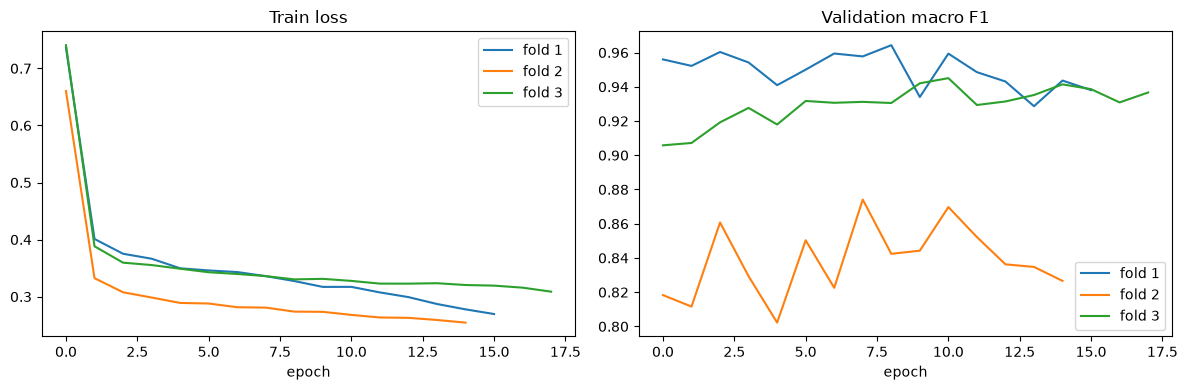

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for fold, history in enumerate(cv_histories, 1):
    axes[0].plot(history["train_loss"], label=f"fold {fold}")
    axes[1].plot(history["val_f1"], label=f"fold {fold}")
axes[0].set_title("Train loss")
axes[1].set_title("Validation macro F1")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "figures/03_transformer_learning_curves.png", dpi=150)
plt.show()


Лучшие эпохи -- `9`, `8`, `11`, то есть Transformer тоже успевает сойтись задолго до лимита. По validation F1 видно, что дальнейшее обучение после пика не дает стабильного выигрыша, поэтому early stopping работает по назначению.


### Финальное обучение и test


In [8]:
final_epochs = int(np.median(cv_df["best_epoch"]))
X_fit, X_holdout, mean, std = standardize(X_train, X_test)
train_loader = make_loader(X_fit, y_train, shuffle=True)
test_loader = make_loader(X_holdout, y_test)

set_seed(SEED)
model = TimeSeriesTransformer().to(device)
final_history, _, final_train_time = fit(model, train_loader, epochs=final_epochs)
test = evaluate(model, test_loader)
latency = latency_ms(model, X_holdout)

print("final epochs:", final_epochs)
print({k: round(v, 4) for k, v in test.items() if not k.startswith("y_")})
print("params:", f"{count_parameters(model):,}")
print("train time, s:", round(final_train_time, 2))
print("latency, ms/sample:", round(latency, 4))


final epochs: 9
{'loss': 0.2547, 'accuracy': 0.9114, 'balanced_accuracy': 0.9125, 'macro_f1': 0.911}
params: 179,718
train time, s: 19.82
latency, ms/sample: 0.0878


На test Transformer дает `0.9114` accuracy и `0.9110` macro F1. Это нормальный baseline, но standard EdgeMTSC выше примерно на `1.8` п.п. macro F1, а pairwise -- примерно на `2.3` п.п. При почти одинаковом числе параметров разница уже не объясняется просто размером модели.


### Анализ ошибок


In [9]:
report = pd.DataFrame(classification_report(
    test["y_true"], test["y_pred"], target_names=CLASS_NAMES, output_dict=True
)).T
report


,precision,recall,f1-score,support
WALKING,0.963362,0.901210,0.931250,496.000000
WALKING_UPSTAIRS,0.971616,0.944798,0.958019,471.000000
WALKING_DOWNSTAIRS,0.886752,0.988095,0.934685,420.000000
SITTING,0.858796,0.755601,0.803900,491.000000
STANDING,0.830688,0.885338,0.857143,532.000000
LAYING,0.962366,1.000000,0.980822,537.000000
accuracy,0.911435,0.911435,0.911435,0.911435
macro avg,0.912263,0.912507,0.910970,2947.000000
weighted avg,0.912209,0.911435,0.910455,2947.000000


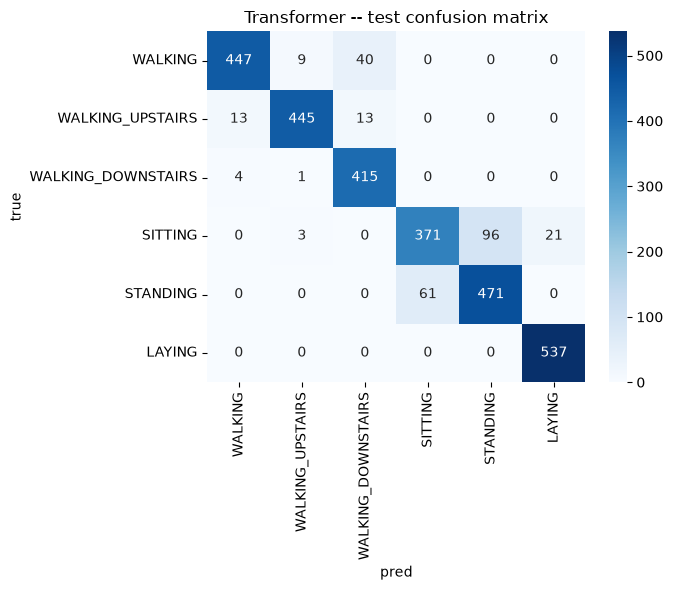

In [10]:
cm = confusion_matrix(test["y_true"], test["y_pred"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("pred")
plt.ylabel("true")
plt.title("Transformer -- test confusion matrix")
plt.tight_layout()
plt.savefig(ROOT / "figures/03_transformer_confusion.png", dpi=150)
plt.show()


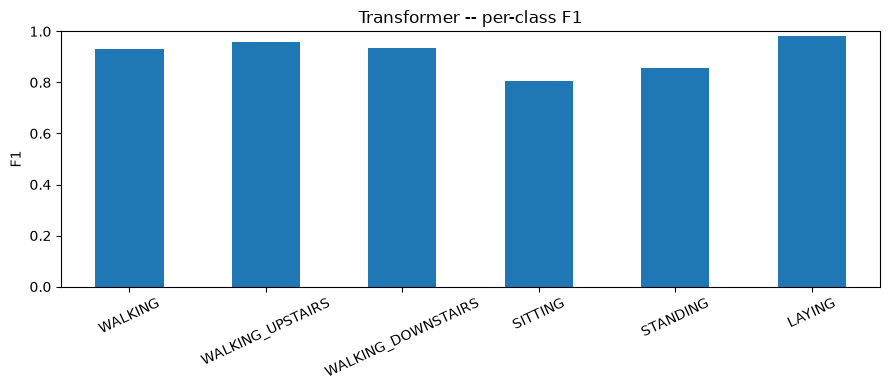

In [11]:
report.loc[CLASS_NAMES, "f1-score"].plot(kind="bar", figsize=(9, 4))
plt.ylim(0, 1)
plt.ylabel("F1")
plt.title("Transformer -- per-class F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(ROOT / "figures/03_transformer_class_f1.png", dpi=150)
plt.show()


Главная просадка снова на `SITTING` -- F1 около `0.80`. На динамических классах Transformer заметно сильнее, но в среднем уступает обеим convolutional моделям. Для UCI HAR это похоже на полезный inductive bias EdgeMTSC: локальные и multiscale временные паттерны здесь оказываются удобнее чистого global attention.


### Attention по времени

Для одного корректно классифицированного test-примера смотрю, куда `CLS` смотрит в последнем слое. Это не отдельная метрика, просто sanity check поведения baseline.


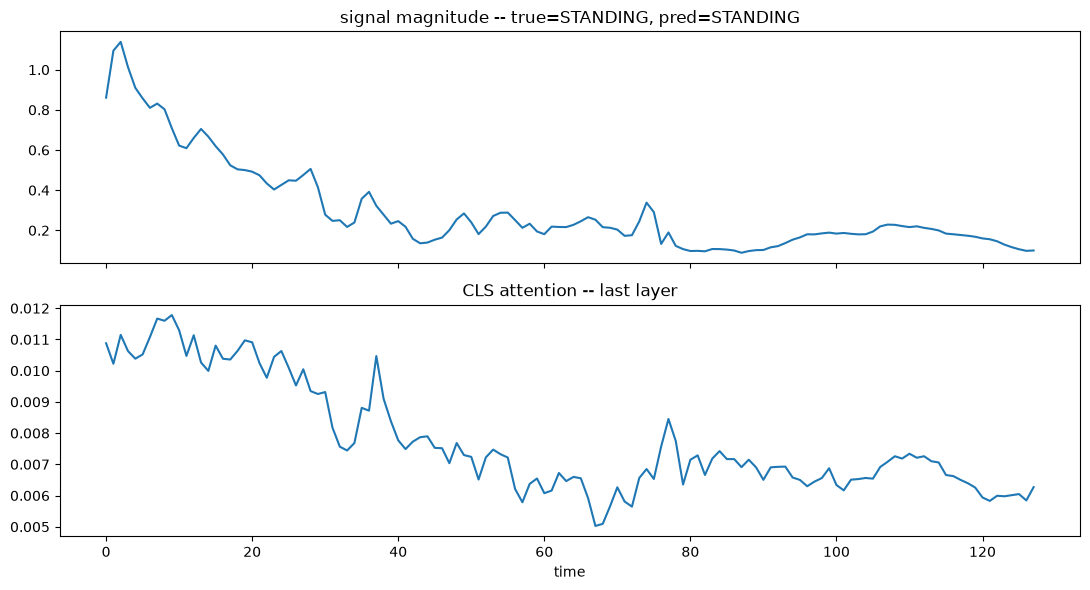

In [12]:
correct = np.where(test["y_true"] == test["y_pred"])[0]
idx = int(correct[0])
x = torch.tensor(X_holdout[idx:idx + 1], dtype=torch.float32, device=device)

model.eval()
with torch.no_grad():
    pred = model(x, save_attention=True).argmax(1).item()

attention = model.layers[-1].last_attention[0, 0, 1:].numpy()
signal = np.sqrt(np.mean(X_holdout[idx, :6] ** 2, axis=0))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(signal)
axes[0].set_title(f"signal magnitude -- true={CLASS_NAMES[y_test[idx]]}, pred={CLASS_NAMES[pred]}")
axes[1].plot(attention)
axes[1].set_title("CLS attention -- last layer")
axes[1].set_xlabel("time")
plt.tight_layout()
plt.savefig(ROOT / "figures/03_transformer_attention.png", dpi=150)
plt.show()


В этом примере `CLS` действительно сильнее смотрит на начало окна, где амплитуда сигнала выше, но attention остается довольно распределенным по всей последовательности. Использую график только как sanity check -- по одному attention profile нельзя делать вывод, что модель именно так принимает решение на всем датасете.


### Сохраняю результат


In [13]:
result = {
    "model": "Transformer",
    "params": count_parameters(model),
    "cv_macro_f1_mean": cv_df["macro_f1"].mean(),
    "cv_macro_f1_std": cv_df["macro_f1"].std(),
    "cv_accuracy_mean": cv_df["accuracy"].mean(),
    "final_epochs": final_epochs,
    "test_accuracy": test["accuracy"],
    "test_balanced_accuracy": test["balanced_accuracy"],
    "test_macro_f1": test["macro_f1"],
    "train_time_s": final_train_time,
    "cv_time_s": cv_df["time_s"].sum(),
    "latency_ms": latency,
}

with open(ROOT / "results/03_transformer.json", "w") as f:
    json.dump(result, f, indent=2)

cv_df.to_csv(ROOT / "results/03_transformer_cv.csv", index=False)
result


{'model': 'Transformer',
 'params': 179718,
 'cv_macro_f1_mean': np.float64(0.9278233438725075),
 'cv_macro_f1_std': np.float64(0.04749979033510488),
 'cv_accuracy_mean': np.float64(0.9269378988781609),
 'final_epochs': 9,
 'test_accuracy': 0.9114353579911775,
 'test_balanced_accuracy': 0.9125070629215676,
 'test_macro_f1': 0.9109698600559355,
 'train_time_s': 19.82256141700782,
 'cv_time_s': np.float64(89.48066791701422),
 'latency_ms': 0.08784274414097126}

## Итоговое сравнение

Здесь уже есть результаты всех трех основных моделей, поэтому собираю общую таблицу и графики.


In [14]:
files = [
    ROOT / "results/01_edgemtsc.json",
    ROOT / "results/02_edgemtsc_pairwise.json",
    ROOT / "results/03_transformer.json",
]

results = []
for path in files:
    with open(path) as f:
        results.append(json.load(f))

comparison = pd.DataFrame(results)
comparison["train_s_per_epoch"] = comparison["train_time_s"] / comparison["final_epochs"]
comparison[[
    "model", "params", "cv_macro_f1_mean", "cv_macro_f1_std",
    "test_accuracy", "test_balanced_accuracy", "test_macro_f1",
    "train_time_s", "train_s_per_epoch", "latency_ms",
]].round(4)


,model,params,cv_macro_f1_mean,cv_macro_f1_std,test_accuracy,test_balanced_accuracy,test_macro_f1,train_time_s,latency_ms
0,EdgeMTSC,180232,0.9300,0.0602,0.9287,0.9306,0.9293,17.6649,0.0600
1,EdgeMTSC-pairwise,181376,0.9374,0.0528,0.9338,0.9350,0.9345,6.4385,0.0310
2,Transformer,179718,0.9278,0.0475,0.9114,0.9125,0.9110,19.8226,0.0878


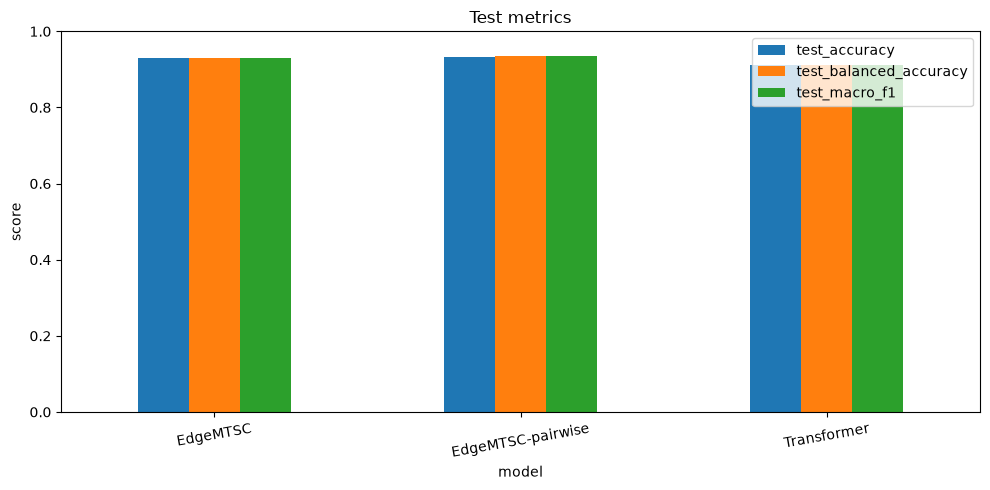

In [15]:
metrics = comparison.set_index("model")[["test_accuracy", "test_balanced_accuracy", "test_macro_f1"]]
metrics.plot(kind="bar", figsize=(10, 5))
plt.ylim(0, 1)
plt.ylabel("score")
plt.title("Test metrics")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(ROOT / "figures/03_comparison_metrics.png", dpi=150)
plt.show()


По всем трем test-метрикам порядок одинаковый: `EdgeMTSC-pairwise > EdgeMTSC > Transformer`. Разница между accuracy, balanced accuracy и macro F1 внутри каждой модели небольшая, поэтому итог не держится на одном удобном классе.


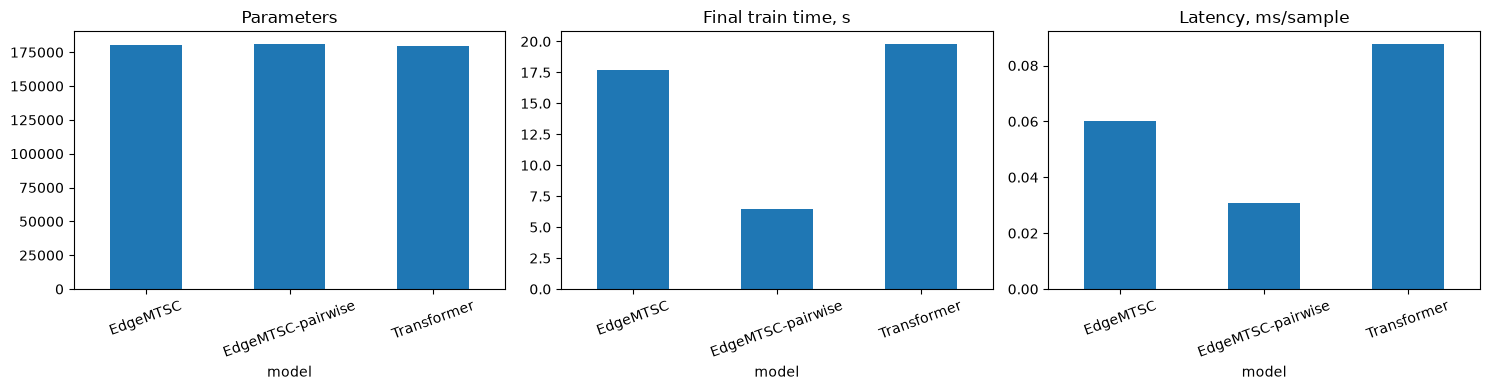

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
comparison.plot.bar(x="model", y="params", ax=axes[0], legend=False, title="Parameters")
comparison.plot.bar(x="model", y="train_s_per_epoch", ax=axes[1], legend=False, title="Train time, s/epoch")
comparison.plot.bar(x="model", y="latency_ms", ax=axes[2], legend=False, title="Latency, ms/sample")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(ROOT / "figures/03_comparison_efficiency.png", dpi=150)
plt.show()


Число параметров отличается меньше чем на `1%`: `179.7k-181.4k`. Для времени обучения честнее смотреть не только полный final fit, потому что модели выбрали разное число эпох (`9 / 4 / 9`), а секунды на эпоху. Pairwise-вариант все равно выходит быстрее за эпоху и по inference latency -- это следствие более узкого backbone при том же parameter budget, а не доказательство, что сам pairwise operator всегда дешевле обычного IMP.


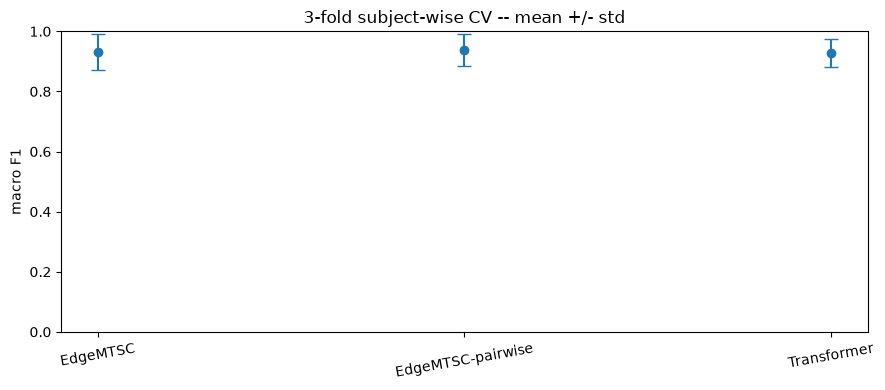

In [17]:
plt.figure(figsize=(9, 4))
plt.errorbar(
    comparison["model"],
    comparison["cv_macro_f1_mean"],
    yerr=comparison["cv_macro_f1_std"],
    fmt="o",
    capsize=5,
)
plt.ylim(0, 1)
plt.ylabel("macro F1")
plt.title("3-fold subject-wise CV -- mean +/- std")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(ROOT / "figures/03_comparison_cv.png", dpi=150)
plt.show()

comparison.to_csv(ROOT / "results/comparison.csv", index=False)


По CV средние значения близки, а error bars заметно перекрываются. Pairwise имеет лучший mean, но разница между архитектурами меньше, чем разброс между subject folds. Поэтому test ranking считаю содержательным результатом конкретного official split, но не заявляю статистически надежное превосходство на всех возможных группах пользователей.


### Обновляю финальный отчет

Последняя ячейка подставляет реальные числа этого запуска в `REPORT.md`. Ничего руками переносить не надо.


In [18]:
edge = comparison.set_index("model").loc["EdgeMTSC"]
pair = comparison.set_index("model").loc["EdgeMTSC-pairwise"]
tr = comparison.set_index("model").loc["Transformer"]
ablation = pd.read_csv(ROOT / "results/01_edge_ablation.csv")

best = comparison.sort_values("test_macro_f1", ascending=False).iloc[0]
imp_delta = ablation.loc[ablation.variant == "full EdgeMTSC", "macro_f1"].iloc[0] - ablation.loc[ablation.variant == "w/o IMP", "macro_f1"].iloc[0]
scale_delta = ablation.loc[ablation.variant == "full EdgeMTSC", "macro_f1"].iloc[0] - ablation.loc[ablation.variant == "single-scale LKB", "macro_f1"].iloc[0]
pair_delta = pair.test_macro_f1 - edge.test_macro_f1
edge_vs_tr = edge.test_macro_f1 - tr.test_macro_f1

rows = "\n".join(
    f"| {r.model} | {int(r.params):,} | {r.cv_macro_f1_mean:.4f} +/- {r.cv_macro_f1_std:.4f} | {r.test_accuracy:.4f} | {r.test_balanced_accuracy:.4f} | {r.test_macro_f1:.4f} | {r.train_s_per_epoch:.2f} | {r.latency_ms:.4f} |"
    for _, r in comparison.iterrows()
)

report_md = f"""# ДЗ 1 -- EdgeMTSC на UCI HAR

> Сорочан Дмитрий, ПАДИИ3

## Постановка задачи

Проверяю EdgeMTSC на многомерных временных данных и отдельно исследую две идеи статьи: межканальные связи и разные temporal scales. Дополнительно проверяю свою модификацию -- отдельный локальный temporal operator для каждой пары latent channels.

Основные модели:

1. `EdgeMTSC` -- IMP + SKB + LKB + sAC по training topology официального repo;
2. `EdgeMTSC-pairwise` -- тот же общий pipeline, но IMP заменен на pairwise temporal kernels;
3. `Transformer` -- baseline без отдельного IMP, архитектура в стиле моей прошлой DL домашки.

## Вычислительная конфигурация

Все эксперименты запускаю локально на `MacBook Pro (Mac16,8)`:

- Apple M4 Pro;
- 14-core CPU (`10P + 4E`);
- 24 GB unified memory;
- PyTorch `MPS`;
- batch size `128`.

Модели специально держу примерно в одном budget около `180k` параметров: этого хватает для нормального качества на UCI HAR, а сравнение не упирается в разницу размеров сетей.

## Протокол обучения

Для всех трех основных моделей оставляю один протокол: `AdamW`, `lr=8e-4`, `weight_decay=1e-3`, `label_smoothing=0.05`, максимум `35` эпох и early stopping с `patience=7`. Валидацию делаю через 3-fold `GroupKFold` по людям.

## Корпус

Использую `UCI Human Activity Recognition Using Smartphones`.

- Hugging Face: https://huggingface.co/datasets/udayl/UCI_HAR
- UCI: https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones
- внешний raw-signal CNN sanity check: https://github.com/healthDataScience/deep-learning-HAR
- 7352 train / 2947 test;
- 9 каналов;
- 128 временных шагов;
- 6 классов;
- official split разделен по людям.

Корпус выбрал из-за сочетания размера, физически связанных sensor channels и нормального subject-independent split. Обучаю все локально на ноуте, поэтому не раздуваю модели без необходимости, но держу их около `180k` параметров -- полученного качества уже хватает для содержательного сравнения. Для raw `9 x 128` сигналов открытый 1D-CNN дает около `93%` accuracy, использую это только как внешний sanity check.

EDA находится в `notebooks/00_EDA.ipynb`.

![classes](figures/00_class_distribution.png)

![signals](figures/00_examples.png)

![corr](figures/00_channel_correlation.png)

## Валидация и leakage

Official test не участвует в нормализации, CV, early stopping, выборе числа эпох или параметров модели. В EDA использую его только для описания готового official split.

На official train делаю 3-fold `GroupKFold` по `subject_id`. На каждом fold z-score считаю только по fold-train. Для финального fit число эпох беру как медиану best epoch из CV, после чего обучаю модель на всем official train и считаю test для уже зафиксированной конфигурации.

`Accuracy` использую как headline-метрику для сравнения с HAR baseline. Для early stopping и основного сравнения моделей использую `macro F1`; дополнительно считаю `balanced accuracy`, per-class F1 и confusion matrix.

## Архитектуры

### EdgeMTSC

Официальный repo: https://github.com/HokyeeJau/EdgeMTSC

Сохраняю основные train-time блоки:

- channel-fixing `1x1 Conv`;
- IMP с residual;
- SKB с depthwise kernels `3` и `1`;
- LKB `K=47` + dilated branches `[5, 23, 3, 3, 3]` / dilations `[1, 2, 21, 19, 17]`;
- sAC из двух классификационных голов.

Structural re-parameterization не включаю -- здесь проверяю качество и идеи representation learning, а не отдельный deployment conversion.

![architecture](docs/assets/edgemtsc_architecture.png)

### Pairwise EdgeMTSC

В standard IMP связь `source -> target` задается одним весом и одинаково действует во времени. В pairwise-варианте каждая пара latent channels получает свой kernel длины 5, то есть banded Toeplitz operator с лагами `[-2, -1, 0, +1, +2]`.

Чтобы сохранить общий budget около `180k`, pairwise backbone делаю уже (`176 -> 44` против `352 -> 88`). Поэтому это fixed-budget comparison двух конфигураций, а не чистая ablation одного оператора при одинаковой ширине сети.

### Transformer

Каждый timestamp -- токен из 9 sensor features. `Linear -> CLS + positional embedding -> 4 Transformer blocks -> classifier`.

Конфигурация: `dim=72`, `4 heads`, `depth=4`, `MLP ratio=2`.

## Результаты

| model | params | CV macro F1 | test accuracy | test balanced acc | test macro F1 | train, s/epoch | latency, ms/sample |
|---|---:|---:|---:|---:|---:|---:|---:|
{rows}

![metrics](figures/03_comparison_metrics.png)

![cv](figures/03_comparison_cv.png)

![efficiency](figures/03_comparison_efficiency.png)

У всех моделей второй subject fold заметно тяжелее первого и третьего. Поэтому большой CV std в первую очередь отражает inter-subject variability. Error bars перекрываются, так что небольшие различия CV mean не трактую как статистически надежное превосходство.

По test все три метрики дают один порядок: `EdgeMTSC-pairwise > EdgeMTSC > Transformer`. Standard EdgeMTSC выше Transformer по macro F1 на `{edge_vs_tr:+.4f}`, pairwise выше standard на `{pair_delta:+.4f}`.

## Абляция EdgeMTSC

На первом subject-wise CV fold отдельно убираю IMP и multiscale dilated branches LKB.

| variant | macro F1 | params |
|---|---:|---:|
""" + "\n".join(
    f"| {r.variant} | {r.macro_f1:.4f} | {int(r.params):,} |" for _, r in ablation.iterrows()
) + f"""

![ablation](figures/01_edge_ablation.png)

На этом fold `full - w/o IMP = {imp_delta:+.4f}`, `full - single-scale LKB = {scale_delta:+.4f}` macro F1. Обе разницы маленькие. Это вспомогательная ablation на одном fold, причем удаление IMP заметно уменьшает parameter count, поэтому не использую эти числа как сильное причинное доказательство. Для UCI HAR корректнее сказать, что отдельный эффект IMP и multiscale LKB здесь небольшой / неубедительный, а полный EdgeMTSC pipeline в целом работает лучше parameter-matched Transformer на official test.

## Анализ ошибок

### EdgeMTSC

![edge cm](figures/01_edge_confusion.png)

### Pairwise EdgeMTSC

![pair cm](figures/02_pairwise_confusion.png)

### Transformer

![tr cm](figures/03_transformer_confusion.png)

Во всех трех моделях основные ошибки приходятся на `SITTING` / `STANDING`. Динамические активности и `LAYING` распознаются заметно лучше. Это согласуется с EDA: статические сигналы похожи и отличаются тоньше, чем просто уровнем активности.

## Вывод

Лучший test macro F1 в этом запуске: `{best.model}` -- `{best.test_macro_f1:.4f}`.

Результаты считаю нормальными: standard EdgeMTSC дает около `92.9%` accuracy, pairwise -- `93.4%`, то есть я попадаю в район внешнего raw-signal CNN sanity check. Увеличивать модели только потому, что полный прогон на MPS занимает несколько минут, смысла не вижу -- по learning curves они уже быстро сходятся, а качество не выглядит заниженным из-за слишком маленькой capacity.

Standard EdgeMTSC обходит parameter-matched Transformer на official test. Это поддерживает полный convolutional + channel-mixing inductive bias EdgeMTSC для сенсорных временных рядов, но короткая ablation не позволяет приписать весь выигрыш именно IMP или именно multiscale LKB.

Pairwise fixed-budget вариант дает еще `{pair_delta:+.4f}` macro F1 относительно standard EdgeMTSC и лучший CV mean. Это небольшой, но содержательный выигрыш. По learned temporal matrix основная масса связи остается около главной диагонали, поэтому на этом корпусе полезнее выглядят локальные lag-aware relations, а не дальние временные переносы. Из-за разной ширины backbone этот эксперимент не является чистой заменой одного блока при полностью одинаковой архитектуре.

По ресурсам все три модели почти одинаковы по parameter count. Pairwise-вариант быстрее за эпоху и по inference latency, потому что fixed budget реализован более узким backbone. Полное final train time напрямую не сравниваю как скорость архитектуры: модели обучались разное число эпох.

## Что еще можно попробовать

- повторить основную таблицу по нескольким seeds;
- сделать ablation IMP / multiscale по всем subject folds, а не только по первому;
- проверить pairwise kernel `3 / 7 / 9` или dilated pairwise kernels;
- structural re-parameterization SKB/LKB и отдельное сравнение latency до/после merge;
- второй корпус из UEA, например `FingerMovements`, где авторы EdgeMTSC отдельно отмечают сильный эффект IMP.
"""

(ROOT / "REPORT.md").write_text(report_md)
print("REPORT.md updated")


REPORT.md updated
